In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from scipy.signal import find_peaks
from scipy.constants import h, c

from basics import load_images, convert_into_array, sort_data, plot_image_profiles
from calibration import k_lambda_fit, fit_B_with_b_k0_uncertainties, lambda_cal, fit_gaussian_intensity_profiles
from fits import single_gaussian_fit, polynomial_fit, polynomial, polyfit_peak

# some constants
p_central = 720
s_p = ufloat(3.45*10**3,0) # pixel size in nm

/home/lorenz/Dokumente/Datenanalyse/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


# Calibration

[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@1278.049] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x80

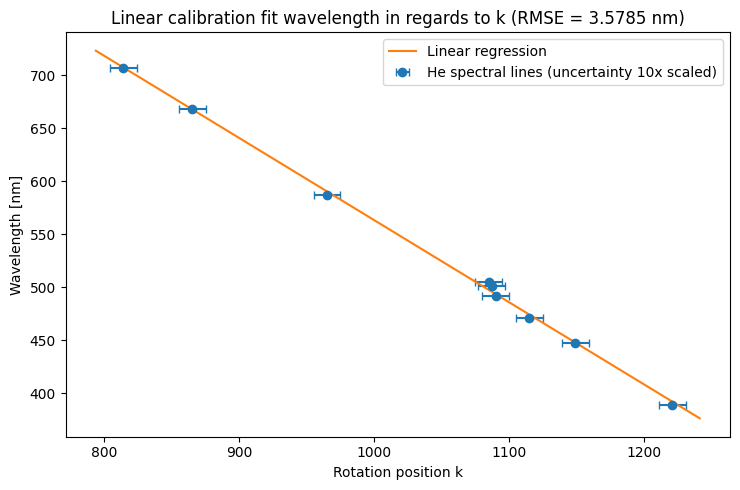

-0.775+/-0.011 1727+/-10


In [53]:
# relation k to lamda
# set folder path
path_k_lamda_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen"
path_k_lamda_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/k_lamda"

# load images, generate 1-D spectra and sort them in a dict
images_k_lamda = load_images(path_k_lamda_Bilder)
images_one_line_k_lambda, raw_one_line_k_lamda = convert_into_array(images_k_lamda)
img_dic_k_lambda = sort_data(path_k_lamda_Bilder, path_k_lamda_Notizen, images_one_line_k_lambda, "k-values")

# define Helium lines
#He_spectrum = np.array([388.8,447.1,471.3,492.1,501.5,504.7,587.5,667.8, 706.5])
He_spectrum = np.array([706.5, 667.8,587.5,504.7,501.5,492.1,471.3,447.1,388.8])
k_measured_lamda = np.array([img_dic_k_lambda[name]['k_value'] for name in img_dic_k_lambda])

# sanity check
if len(He_spectrum) != len(k_measured_lamda):
    raise Exception("Zu viele oder zu wenig Linien detektiert :/")

# uncertainties
sigma_k_lambda = np.ones_like(k_measured_lamda)
sigma_lambda = None

# linear fit for relation, k and lamda
b, k0 = k_lambda_fit(He_spectrum, k_measured_lamda, sigma_k_lambda)
print(b,k0)

[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@1279.235] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x80

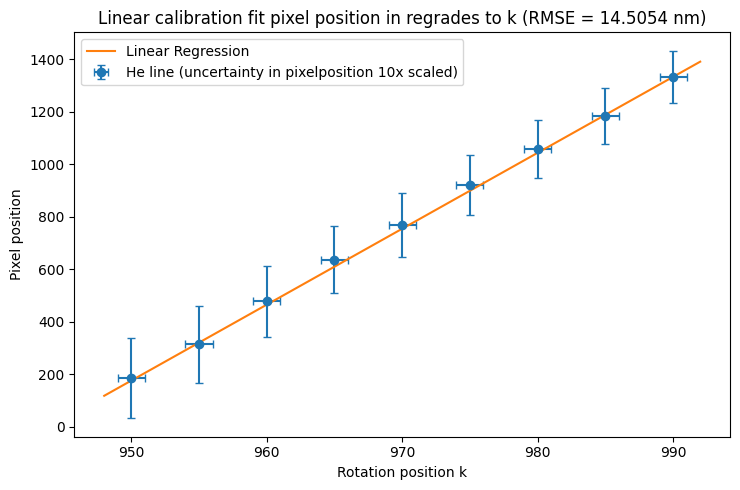

-28.9+/-0.4


In [54]:
# relation k to p
# set folder path
path_p_k_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen"
path_p_k_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/p_cal"

# load images, generate 1-D spectra and sort them in a dict
images_p_k = load_images(path_p_k_Bilder)
images_one_line_p_k, raw_one_line_p_k = convert_into_array(images_p_k )
img_dic_p_k = sort_data(path_p_k_Bilder, path_p_k_Notizen, images_one_line_p_k, "p_cal")

# fit gaussian curve for every calibration image
fit_results_p_k = fit_gaussian_intensity_profiles(img_dic_p_k)
lambda0 = 587.5 # adjust

# linear fit for relation, k and px
B = fit_B_with_b_k0_uncertainties(img_dic_p_k, fit_results_p_k,b,k0,lambda0,p_central)

print(B)

# Free Spectral Range

[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@1280.400] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x80

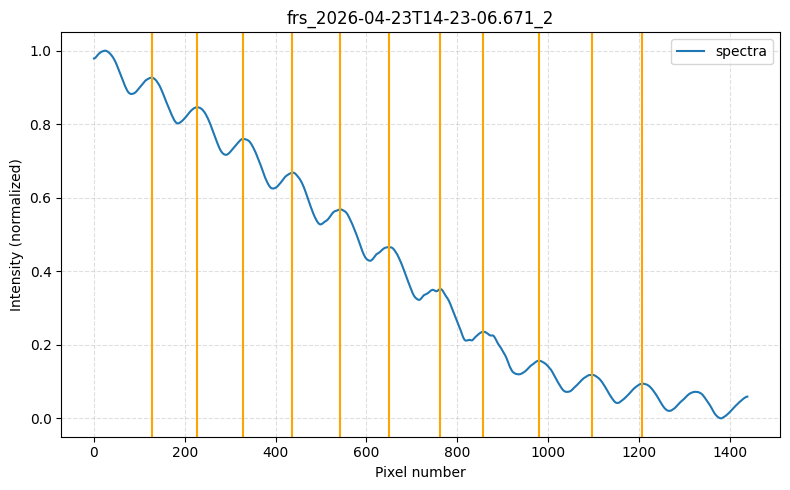

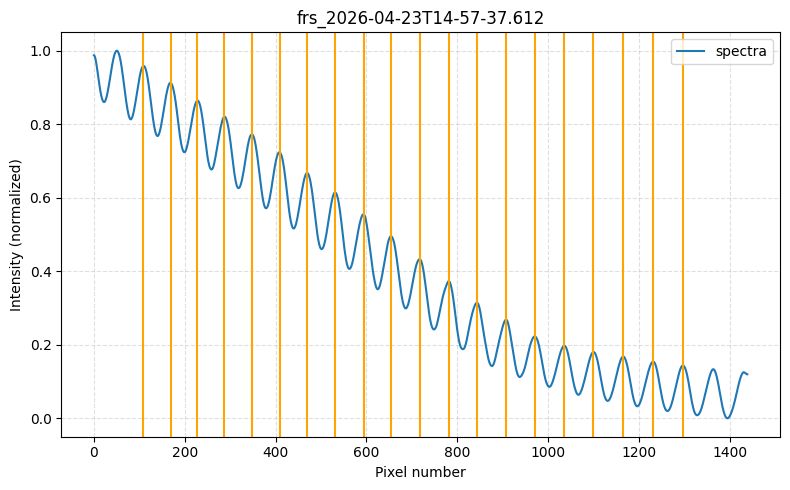

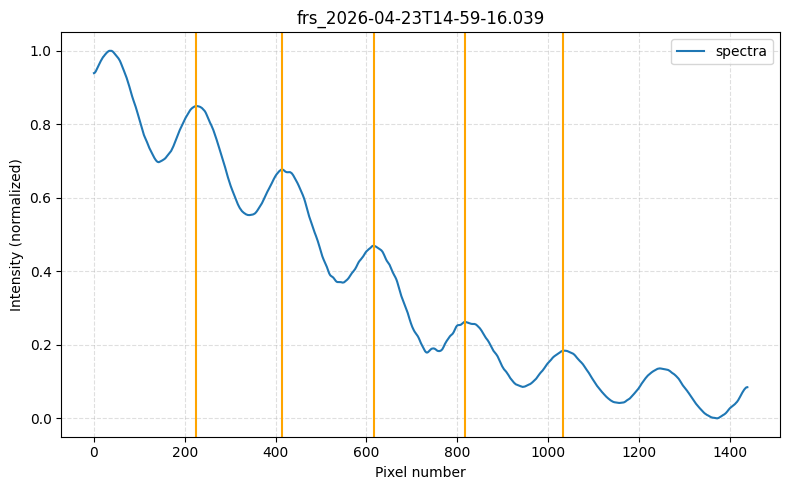

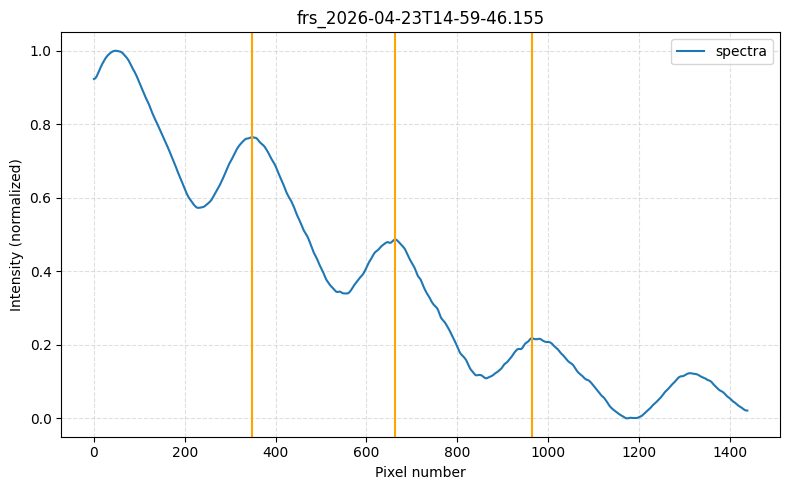

frs_2026-04-23T14-23-06.671_2: FSR = $(2.90 \pm 0.06)\,\mathrm{nm}$, l = $(64 \pm 2)\,\mathrm{µm}$
frs_2026-04-23T14-57-37.612: FSR = $(1.7 \pm 0.1)\,\mathrm{nm}$, l = $(\left(1.1 \pm 0.1\right) \times 10^{2})\,\mathrm{µm}$
frs_2026-04-23T14-59-16.039: FSR = $(5.4 \pm 0.2)\,\mathrm{nm}$, l = $(34 \pm 2)\,\mathrm{µm}$
frs_2026-04-23T14-59-46.155: FSR = $(8 \pm 2)\,\mathrm{nm}$, l = $(22 \pm 4)\,\mathrm{µm}$


In [55]:
# define folder paths
path_frs_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen/"
path_frs_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/frs"

# load images, generate 1-D spectra and sort them in a dict
images_frs = load_images(path_frs_Bilder)
images_one_line_frs, raw_one_line_frs = convert_into_array(images_frs)
img_dic_frs = sort_data(path_frs_Bilder, path_frs_Notizen, images_one_line_frs, "frs")

# calculate peaks and free spectral range
for name in img_dic_frs:
    # extract spectra
    spectra = img_dic_frs[name]["pixel_values"]

    # find peaks
    peak_indices, properties = find_peaks(spectra, prominence=0.02)
    peak_indices = peak_indices[1:-1]

    plt.figure(figsize=(8, 5))
    plt.title(name)
    plt.style.use('default')
    plt.plot(np.arange(0, len(spectra)), spectra, label="spectra")
    for indice in range(len(peak_indices)):
        plt.axvline(x=peak_indices[indice], color='orange')
    plt.xlabel("Pixel number")
    plt.ylabel("Intensity (normalized)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # create uncertainty array for peaks
    peak_u = unumpy.uarray(peak_indices, np.zeros_like(peak_indices))

    # fit gaussian through each peak to calculate uncertainty
    for i in range(len(peak_indices)):
        # extract peak indices and define fit range
        current_peak = peak_indices[i]
        if i < len(peak_indices) - 1:
            next_peak = peak_indices[i+1]
            middle_index_next = current_peak + np.abs(current_peak-next_peak)//8 # estimated index between current peak and the next one
        else:
            middle_index_next = current_peak+25
        if i == 0:
            middle_index_last = current_peak-25
        else:
            last_peak = peak_indices[i-1]
            middle_index_last = current_peak - np.abs(current_peak-last_peak)//8 # estimated index between current peak and the last one

        #if i < len(peak_indices) - 1 and i != 0:
        x = np.arange(middle_index_last, middle_index_next)

        # create uncertainty value
        peak_u[i] = polyfit_peak(x, spectra[middle_index_last:middle_index_next])

    # extract k and convert pixel values to wavelength
    k_frs = ufloat(img_dic_frs[name]["k_value"], 1)
    peak_lambda = lambda_cal(b, k0, p_central, B, k_frs, peak_u)

    # calculate free spectral range (possible problems when combining numpy and uncertainties package)
    diffs = [peak_lambda[i+1] - peak_lambda[i] for i in range(len(peak_lambda)-1)]
    fsr = sum(diffs) / len(diffs)

    # store results in dictionary
    img_dic_frs[name]["fsr"] = fsr
    img_dic_frs[name]["peaks"] = peak_lambda

# function which returns de distance between the two mirrors
def mirror_distance(wavelength, fsr):
    return ((wavelength**2 / fsr) - wavelength) * 0.5

# output free spectral range and the distance between the mirrors for every image
for name in img_dic_frs:
    fsr = img_dic_frs[name]['fsr']
    peaks = img_dic_frs[name]['peaks']
    l_arr = mirror_distance(img_dic_frs[name]['peaks'], img_dic_frs[name]['fsr']) * 1e-3
    l_mean = sum(l_arr) / len(l_arr)

    print(f"{name}: FSR = $({fsr:.1uL})\\,\\mathrm{{nm}}$, l = $({l_mean:.1uL})\\,\\mathrm{{µm}}$")

# Cavity dispersion

In [56]:
# define folder paths
path_disp_Notizen = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Notizen/"
path_disp_Bilder = "/home/lorenz/Dokumente/Datenanalyse/P2/Spectroscopy_3/Bilder/dispersion"

# load images, generate 1-D spectra and sort them in a dict
images_disp = load_images(path_disp_Bilder)
images_one_line_disp, raw_one_line_disp = convert_into_array(images_disp)
img_dic_disp = sort_data(path_disp_Bilder, path_disp_Notizen, images_one_line_disp, "dispersion")

# load theta values
theta_measured = np.loadtxt(os.path.join(path_disp_Notizen, "theta.txt"), delimiter=',')[:, 1]

# get image names in the same order as in sort_data
filenames = sorted([f for f in os.listdir(path_disp_Bilder)])
names = [os.path.splitext(f)[0] for f in filenames]


# attach theta to dictionary
for name, theta in zip(names, theta_measured):
    img_dic_disp[name]["theta"] = theta

# sort by ascending theta
sorted_names = sorted(img_dic_disp, key=lambda name: img_dic_disp[name]["theta"])

# choose one peak in first spectrum
first_name = sorted_names[0]
first_spectrum = img_dic_disp[first_name]["pixel_values"]

# choose trackable peak by looking which is the nearest to the center of the image
peak_indices, properties = find_peaks(first_spectrum)
tracked_peak = peak_indices[np.argmin(np.abs(peak_indices - p_central))]

# track peak through all spectra
for name in sorted_names:
    # extract spectrum and metadata
    spectra = img_dic_disp[name]["pixel_values"]
    theta = img_dic_disp[name]["theta"]
    k_val = img_dic_disp[name]["k_value"]

    # find peaks
    peak_indices, properties = find_peaks(spectra)

    # choose peak closest to previous one
    i_peak = np.argmin(np.abs(peak_indices - tracked_peak))
    current_peak = peak_indices[i_peak]

    # define fit range
    if i_peak < len(peak_indices) - 1:
        next_peak = peak_indices[i_peak + 1]
        middle_index_next = current_peak + np.abs(current_peak - next_peak) // 2
    else:
        middle_index_next = len(spectra) - 1

    if i_peak == 0:
        middle_index_last = 0
    else:
        last_peak = peak_indices[i_peak - 1]
        middle_index_last = current_peak - np.abs(current_peak - last_peak) // 2

    x = np.arange(middle_index_last, middle_index_next)

    # create uncertainty value
    peak_px = polyfit_peak(x, spectra[middle_index_last:middle_index_next])

    # convert to wavelength
    peak_lambda = lambda_cal(b, k0, p_central, B, k_val, peak_px)

    # store result
    img_dic_disp[name]["tracked_peak_lambda"] = peak_lambda

    # update tracked peak position
    tracked_peak = peak_px

# calculate energies from wavelengths
for name in img_dic_disp:
    img_dic_disp[name]["energy"] = h * c / img_dic_disp[name]["tracked_peak_lambda"]

# extract energies and angles in arrays for plotting
energies = np.array([img_dic_disp[name]["energy"].n for name in img_dic_disp])
energies_sigma = np.array([img_dic_disp[name]["energy"].s for name in img_dic_disp])
thetas = np.array([img_dic_disp[name]["theta"] for name in img_dic_disp])

# x- and y-axis for the fit
theta_min, theta_max = np.min(thetas), np.max(thetas)
theta_pad = 0.05 * (theta_max - theta_min)
theta_fit = np.linspace(theta_min - theta_pad, theta_max + theta_pad, 1000)

a, c, d, e, f = polynomial_fit(thetas, energies, 0, energies_sigma)
energies_fit = polynomial([a.n, c.n, d.n, e.n, f.n], theta_fit)

# RSME
energies_fit_data = polynomial([a.n, c.n, d.n, e.n, f.n], thetas)
residuals = energies - energies_fit_data
rmse = np.sqrt(np.mean(residuals ** 2))

# plot
plt.figure(figsize=(7.5, 5))
plt.style.use('default')
plt.errorbar(thetas, energies, xerr=0, yerr=energies_sigma, fmt='o', capsize=3, label='Energy')
plt.plot(theta_fit, energies_fit, '-', label=rf"polynomial fit (RMSE = {rmse:.4f} J)")
plt.xlabel('θ [°]')
plt.ylabel('Energy [J]')
plt.title(f'Correlation between incident angle and corresponding energy to a transmission mode')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('cavity_dispersion.png', dpi=600)
plt.show()

[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32768 (0x8000) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32769 (0x8001) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32770 (0x8002) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32771 (0x8003) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32772 (0x8004) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32773 (0x8005) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32774 (0x8006) encountered
[ WARN:0@1281.382] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 32775 (0x80

KeyError: 'dispersion_2026-04-23T15-24-20.577'